# **Exercicio Duelo de Modelos 4**

Nesta tarefa, vocês irão criar o seu próprio duelo de modelos, com o objetivo de superar os resultados apresentados em aula. O desafio é alcançar um desempenho superior ao que obtivemos, e para isso, será necessário aplicar todas as melhorias que vocês aprenderam ao longo dos módulos, utilizando a base de dados do Titanic.

**1. Escolha do Modelo:**
Selecione um dos modelos que foram explorados nos duelos de modelos ao longo do curso. Pode ser SVM, Random Forest, XGBoost, ou qualquer outro que tenhamos abordado.

**2. Aperfeiçoamento:**
**Aplique as técnicas que aprendemos para melhorar o desempenho do seu modelo:**

**Hiperparâmetros:** Utilize GridSearchCV ou RandomSearchCV para encontrar os melhores parâmetros.

**Cross Validation:** Avalie a robustez do modelo utilizando validação cruzada para garantir que ele generaliza bem.

**Balanceamento de Classes:** Se o seu modelo lida com problemas de classes desbalanceadas, explore técnicas como SMOTE, undersampling ou oversampling.

**Padronização e Normalização:** Lembre-se de padronizar os dados, especialmente se for usar modelos que são sensíveis à escala das variáveis.

**3. Submissão no Kaggle:**
Treine o seu modelo com os dados de treino e gere as previsões para os dados de teste. Lembre-se de que o conjunto de teste não possui a variável alvo (y_test), pois a avaliação será feita com base nas submissões no Kaggle.
Submeta suas previsões na competição do Titanic no Kaggle.

**4. Entrega:**
Envie o código que você desenvolveu, detalhando cada etapa do seu processo de modelagem, explicando as escolhas feitas e como essas ajudaram a melhorar o modelo.

Junto com o código, envie um print do seu score obtido na plataforma do Kaggle. Esse score será a sua métrica final de avaliação, mostrando como o seu modelo se compara com os demais.

**5. Competição Saudável:**
A ideia é trazer um senso de competição saudável, então não vale replicar exatamente o que fizemos na aula! Inove, explore novas combinações de parâmetros e técnicas, e mostre do que é capaz. O importante é exercitar o pensamento crítico e a capacidade de experimentar.

**Dicas Finais:**

Seja criativo e tenha um olhar crítico sobre o que pode ser melhorado.
Teste diferentes abordagens e não se prenda a um único caminho.
Lembre-se de que, mais do que alcançar o melhor score, o objetivo é aprender e aplicar o conhecimento de forma prática e eficaz.
Boa sorte! Estamos ansiosos para ver como cada um de vocês vai se sair nesse desafio e quais insights irão surgir dessa competição!

Ao final dessa atividade vocês terão participado da primeira competição publica de ciência de dados de vocês = )




In [14]:
#Bliblioteca para manipulação de dados
import pandas as pd
import numpy as np

#Biblioteca para visualização de dados
import matplotlib.pyplot as plt     
import seaborn as sns   

#Biblioteca para pré-processamento e modelagem
from sklearn.model_selection import train_test_split    
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.decomposition import PCA

#Biblioteca para construção de modelos
import xgboost as xgb
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

#Biblioteca para avaliação de modelos
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve, accuracy_score



Etapa - Importação e tratamento da base

In [15]:

train = pd.read_csv('Titan_train.csv')
test = pd.read_csv('Titan_test.csv')  

train.head(10)

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True
5,0005_01,Earth,False,F/0/P,PSO J318.5-22,44.0,False,0.0,483.0,0.0,291.0,0.0,Sandie Hinetthews,True
6,0006_01,Earth,False,F/2/S,TRAPPIST-1e,26.0,False,42.0,1539.0,3.0,0.0,0.0,Billex Jacostaffey,True
7,0006_02,Earth,True,G/0/S,TRAPPIST-1e,28.0,False,0.0,0.0,0.0,0.0,NaN,Candra Jacostaffey,True
8,0007_01,Earth,False,F/3/S,TRAPPIST-1e,35.0,False,0.0,785.0,17.0,216.0,0.0,Andona Beston,True
9,0008_01,Europa,True,B/1/P,55 Cancri e,14.0,False,0.0,0.0,0.0,0.0,0.0,Erraiam Flatic,True


In [16]:
test.head(10)


,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez
5,0027_01,Earth,False,F/7/P,TRAPPIST-1e,31.0,False,0.0,1615.0,263.0,113.0,60.0,Karlen Ricks
6,0029_01,Europa,True,B/2/P,55 Cancri e,21.0,False,0.0,NaN,0.0,0.0,0.0,Aldah Ainserfle
7,0032_01,Europa,True,D/0/S,TRAPPIST-1e,20.0,False,0.0,0.0,0.0,0.0,0.0,Acrabi Pringry
8,0032_02,Europa,True,D/0/S,55 Cancri e,23.0,False,0.0,0.0,0.0,0.0,0.0,Dhena Pringry
9,0033_01,Earth,False,F/7/S,55 Cancri e,24.0,False,0.0,639.0,0.0,0.0,0.0,Eliana Delazarson


Tratamento dos dados para a modelagem

In [17]:

def preprocess(df):
    df = df.copy()

    df['Cabin'] = df['Cabin'].fillna('-').astype(str).str[0]#Usar apenas a letra inicial da cabine, para agrupar categorias semelhantes
    df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)
    df['VIP'] = df['VIP'].fillna(False).astype(bool)
    df['HomePlanet'] = df['HomePlanet'].fillna('Unknown')
    df['Destination'] = df['Destination'].fillna('Unknown')
    df['Age'] = df['Age'].fillna(df['Age'].mean())
    df['RoomService'] = df['RoomService'].fillna(0)
    df['FoodCourt'] = df['FoodCourt'].fillna(0)
    df['ShoppingMall'] = df['ShoppingMall'].fillna(0)
    df['Spa'] = df['Spa'].fillna(0)
    df['VRDeck'] = df['VRDeck'].fillna(0)
    df['Name'] = df['Name'].fillna('Unknown')

    return df

train = preprocess(train)
test = preprocess(test) 



C:\Users\celia\AppData\Local\Temp\ipykernel_2632\774023397.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['CryoSleep'] = df['CryoSleep'].fillna(False).astype(bool)
C:\Users\celia\AppData\Local\Temp\ipykernel_2632\774023397.py:6: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df['VIP'] = df['VIP'].fillna(False).astype(bool)
C:\Users\celia\AppData\Local\Temp\ipykernel_2632\774023397.py:5: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) 

In [18]:
columns_cat = train.select_dtypes(include=['object']).columns
columns_cat = columns_cat.drop(['PassengerId', 'Name'])
print("Colunas categóricas:", columns_cat.tolist())

train = pd.get_dummies(train, columns=columns_cat, drop_first=True)
test  = pd.get_dummies(test, columns=columns_cat, drop_first=True)

# alinhar colunas
train, test = train.align(test, join='left', axis=1, fill_value=0)




Colunas categóricas: ['HomePlanet', 'Cabin', 'Destination']


Aqui vamos separar nossa base, filtrar com as principais variaveis.

In [19]:
x_train = train.drop(columns=['Transported', 'PassengerId', 'Name'])
y_train = train['Transported']

x_test = test.drop(columns=['Transported', 'PassengerId', 'Name'], errors='ignore')


pca = PCA(n_components=20)
x_pca = pca.fit_transform(x_train)

y_train.value_counts()


Transported
True     4378
False    4315
Name: count, dtype: int64

Aqui vemos que nosso alvo esta equilibrado, não havendo necessidade  de balancear utilizando Smote

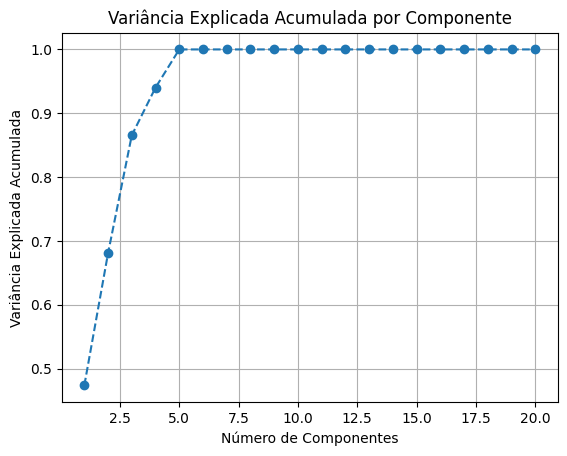

In [20]:
# Variância explicada por cada componente
explained_variance = pca.explained_variance_ratio_

# Variância explicada acumulada
cumulative_variance = explained_variance.cumsum()

# Plotando a variância explicada acumulada
plt.plot(range(1, 21), cumulative_variance, marker='o', linestyle='--')
plt.title('Variância Explicada Acumulada por Componente')
plt.xlabel('Número de Componentes')
plt.ylabel('Variância Explicada Acumulada')
plt.grid(True)
plt.show()

Aqui oberservamos que 5 variaveis explica todo o modelo.


Criando meu pipeline pra rodar o modelo usando cross-validation

In [21]:
from imblearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)

pipe = Pipeline([
    ('pca', PCA(n_components=5)),#Reduzir a dimensionalidade para 5 componentes principais como visto no gráfico anterior.
    ('scaler', StandardScaler()),#Normalizar os dados, Embora o XGBoost não exija normalização,só para garantir que features estejam na mesma escala.
    ('smote', SMOTE(random_state=1)),#Balancear o nossa base de treino embora não esteja tão desbalanceada. 
    ('xgb', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=42
    ))
])


In [22]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CryoSleep                  8693 non-null   bool   
 1   Age                        8693 non-null   float64
 2   VIP                        8693 non-null   bool   
 3   RoomService                8693 non-null   float64
 4   FoodCourt                  8693 non-null   float64
 5   ShoppingMall               8693 non-null   float64
 6   Spa                        8693 non-null   float64
 7   VRDeck                     8693 non-null   float64
 8   HomePlanet_Europa          8693 non-null   bool   
 9   HomePlanet_Mars            8693 non-null   bool   
 10  HomePlanet_Unknown         8693 non-null   bool   
 11  Cabin_A                    8693 non-null   bool   
 12  Cabin_B                    8693 non-null   bool   
 13  Cabin_C                    8693 non-null   bool 

In [23]:
y_train.info()

<class 'pandas.core.series.Series'>
RangeIndex: 8693 entries, 0 to 8692
Series name: Transported
Non-Null Count  Dtype
--------------  -----
8693 non-null   bool 
dtypes: bool(1)
memory usage: 8.6 KB


Avaliando nosso modelo primário

In [24]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    pipe,
    x_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

modelo_xgboost = pd.DataFrame(scores).mean()
pd.DataFrame(scores).mean()

fit_time          0.150539
score_time        0.023359
test_accuracy     0.781432
test_precision    0.759396
test_recall       0.828684
test_f1           0.792454
test_roc_auc      0.846597
dtype: float64

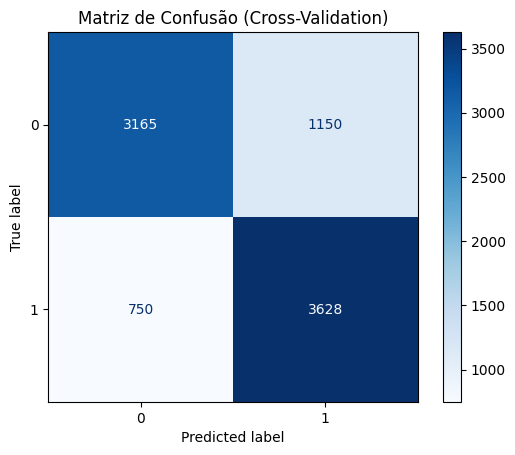

In [25]:
from sklearn.model_selection import cross_val_predict, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_cv = cross_val_predict(
    pipe,
    x_train,
    y_train,
    cv=cv
)

cm = confusion_matrix(y_train, y_pred_cv)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão (Cross-Validation)')
plt.show()

O modelo apresenta um resultado bom, trazendo boas metricas, classificando bem as classes 1 (pessoas que não sobreviveram), que é nosso alvo principal,  mas vamos tentar melhora.

Aqui vamos buscar os melhores parametros para o modelo e ver se melhora nossos resultados. 

In [26]:

param_dist = {
    'xgb__n_estimators': [100, 200, 300, 500],
    'xgb__max_depth': [3, 4, 5, 6],
    'xgb__learning_rate': [0.01, 0.05, 0.1],
    'xgb__subsample': [0.7, 0.8, 0.9, 1.0],
    'xgb__colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'xgb__min_child_weight': [1, 3, 5],
    'xgb__gamma': [0, 0.1, 0.2]
}
random_search = RandomizedSearchCV(
    estimator=pipe,
    param_distributions=param_dist,
    n_iter=30,
    scoring={
        'roc_auc': 'roc_auc',
        'accuracy': 'accuracy',
        'f1': 'f1'
    },
    refit='roc_auc',
    cv=cv,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_search.fit(x_train, y_train)

Fitting 5 folds for each of 30 candidates, totalling 150 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_distributions,"{'xgb__colsample_bytree': [0.7, 0.8, ...], 'xgb__gamma': [0, 0.1, ...], 'xgb__learning_rate': [0.01, 0.05, ...], 'xgb__max_depth': [3, 4, ...], ...}"
,n_iter,30
,scoring,"{'accuracy': 'accuracy', 'f1': 'f1', 'roc_auc': 'roc_auc'}"
,n_jobs,-1
,refit,'roc_auc'
,cv,StratifiedKFo... shuffle=True)
,verbose,1
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [27]:
best_model = random_search.best_estimator_

print("Melhores parâmetros:")
print(random_search.best_params_)

print("ROC AUC médio CV:")
print(random_search.best_score_)


Melhores parâmetros:
{'xgb__subsample': 0.9, 'xgb__n_estimators': 300, 'xgb__min_child_weight': 1, 'xgb__max_depth': 3, 'xgb__learning_rate': 0.1, 'xgb__gamma': 0, 'xgb__colsample_bytree': 1.0}
ROC AUC médio CV:
0.8528485933639158


In [28]:
from sklearn.model_selection import cross_validate

scores = cross_validate(
    best_model,
    x_train,
    y_train,
    cv=cv,
    scoring=['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
)

modelo_Xboost_plus = pd.DataFrame(scores).mean()
pd.DataFrame(scores).mean()

fit_time          0.175019
score_time        0.022222
test_accuracy     0.792821
test_precision    0.765436
test_recall       0.849014
test_f1           0.805001
test_roc_auc      0.851577
dtype: float64

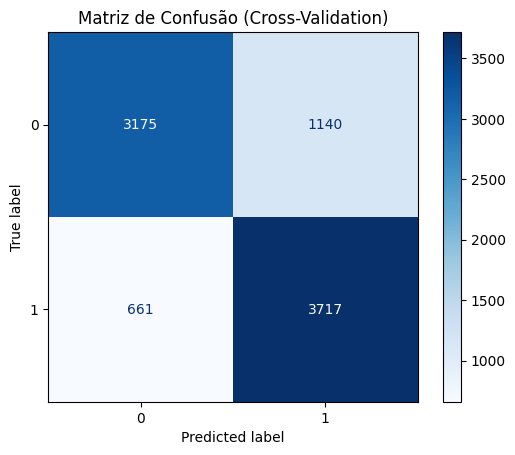

In [29]:
from sklearn.model_selection import StratifiedKFold, cross_val_predict, RandomizedSearchCV
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred_cv = cross_val_predict(
    best_model,
    x_train,
    y_train,
    cv=cv
)

cm = confusion_matrix(y_train, y_pred_cv)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Matriz de Confusão (Cross-Validation)')
plt.show()

Comparaçaõ entre os modelos!!

In [30]:
aval_modelo = modelo_Xboost_plus - modelo_xgboost
aval_modelo

fit_time          0.024480
score_time       -0.001137
test_accuracy     0.011389
test_precision    0.006040
test_recall       0.020331
test_f1           0.012547
test_roc_auc      0.004981
dtype: float64

Aqui o ultimo modelo apresenta levemente melhores resultados, agora vou tentar melhorar o modelo de acordo com o problema, ajustado o Threshold ideal.

In [31]:
from sklearn.model_selection import cross_val_predict

y_proba_inv = cross_val_predict(
    best_model,
    x_train,
    y_train,
    cv=cv,
    method='predict_proba'
)[:, 1]  # probabilidade de MORTE


In [32]:
import numpy as np
from sklearn.metrics import recall_score, precision_score, f1_score

thresholds = np.arange(0.1, 0.9, 0.05)# Definindo uma faixa de thresholds de 0.1 a 0.85 com passo de 0.05

resultados = []

# cálculo das métricas para cada threshold
for t in thresholds:
    y_pred_t = (y_proba_inv >= t).astype(int)
    
    resultados.append({
        'threshold': t,
        'recall_morte': recall_score(y_train, y_pred_t),
        'precision_morte': precision_score(y_train, y_pred_t),
        'f1_morte': f1_score(y_train, y_pred_t)
    })

df_thresh = pd.DataFrame(resultados)
df_thresh


,threshold,recall_morte,precision_morte,f1_morte
0,0.10,0.974646,0.580860,0.727909
1,0.15,0.952033,0.624513,0.754253
2,0.20,0.927593,0.673243,0.780211
3,0.25,0.909776,0.704956,0.794376
4,0.30,0.899726,0.722487,0.801424
5,0.35,0.885336,0.735903,0.803733
6,0.40,0.875971,0.746835,0.806265
7,0.45,0.863408,0.754943,0.805541
8,0.50,0.849018,0.765287,0.804981
9,0.55,0.822293,0.774693,0.797784


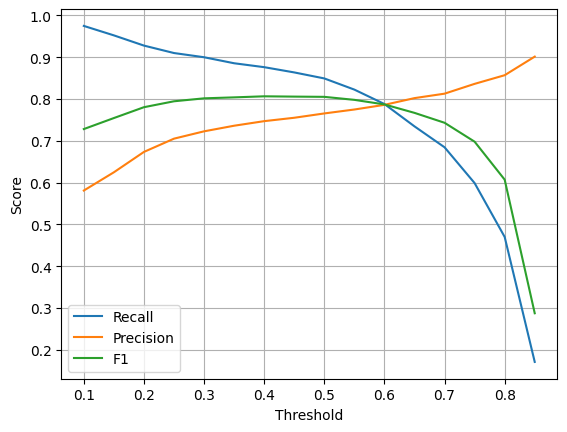

In [33]:
import matplotlib.pyplot as plt

plt.plot(df_thresh['threshold'], df_thresh['recall_morte'], label='Recall')
plt.plot(df_thresh['threshold'], df_thresh['precision_morte'], label='Precision')
plt.plot(df_thresh['threshold'], df_thresh['f1_morte'], label='F1')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.legend()
plt.grid(True)
plt.show()


Aqui vemos que, o Threshold em 0.60 é o ideal, pois acima dele nossas metricas F1 e Recall pioram muito, e a precisão do modelo tem uma leve melhora.

In [34]:
test_proba_inv = best_model.predict_proba(x_test)[:, 1]


In [35]:
threshold_final = 0.60  
y_test_final = (test_proba_inv >= threshold_final).astype(int)


In [36]:
submission = pd.DataFrame({
    'PassengerId': test['PassengerId'],
    'Transported': y_test_final
})

submission.to_csv('submission_titanic.csv', index=False)

In [37]:
submission.head()

,PassengerId,Transported
0,0013_01,1
1,0018_01,0
2,0019_01,1
3,0021_01,1
4,0023_01,1
